# Classificador de Sentimentos — Reclamações Bancárias

## Objetivo
Fine-tuning do DistilBERT para classificar reclamações bancárias
como disputadas (insatisfeito) ou não disputadas (satisfeito).

## Abordagem
Transfer Learning — aproveitamos o conhecimento linguístico do
DistilBERT pré-treinado e ajustamos para nossa tarefa específica.

In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Verifica se GPU está disponível
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo: {device}")
print(f"PyTorch versão: {torch.__version__}")

Dispositivo: cpu
PyTorch versão: 2.10.0+cpu


## 1. Preparando os Dados

In [2]:
# Carrega dados do EDA
df = pd.read_csv('../data/raw/rows.csv', low_memory=False)

# Aplica filtros do EDA
df_filtrado = df[
    (df['Consumer complaint narrative'].notna()) &
    (df['Consumer consent provided?'] == 'Consent provided') &
    (df['Consumer disputed?'].notna())
].copy()

# Cria label binário
df_filtrado['label'] = (df_filtrado['Consumer disputed?'] == 'Yes').astype(int)

# Amostra balanceada — 1000 por classe
df_pos = df_filtrado[df_filtrado['label'] == 0].sample(1000, random_state=42)
df_neg = df_filtrado[df_filtrado['label'] == 1].sample(1000, random_state=42)
df_sample = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=42)

print(f"Dataset para treino: {len(df_sample)} registros")
print(f"Distribuição:\n{df_sample['label'].value_counts()}")

Dataset para treino: 2000 registros
Distribuição:
label
1    1000
0    1000
Name: count, dtype: int64


## 2. Tokenização

In [3]:
# Carrega o tokenizador do DistilBERT
print("Carregando tokenizador...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Exemplo de tokenização
texto_exemplo = df_sample['Consumer complaint narrative'].iloc[0][:200]
tokens = tokenizer(texto_exemplo, truncation=True, max_length=512)

print(f"\nExemplo de texto:")
print(texto_exemplo)
print(f"\nTokens gerados: {len(tokens['input_ids'])}")
print(f"Primeiros 10 tokens: {tokens['input_ids'][:10]}")
print(f"\nDecodificando de volta:")
print(tokenizer.decode(tokens['input_ids'][:10]))

Carregando tokenizador...

Exemplo de texto:
We have received phone calls on XXXX/XXXX/15, XXXX/XXXX/15, XXXX/XXXX/15, XXXX/XXXX/15, XXXX/XXXX/15, XXXX/XXXX/15, XXXX/XXXX/15, XXXX/XXXX/15, XXXX/XXXX/15 from this company and I continue to call th

Tokens gerados: 88
Primeiros 10 tokens: [101, 2057, 2031, 2363, 3042, 4455, 2006, 22038, 20348, 1013]

Decodificando de volta:
[CLS] we have received phone calls on xxxx /


## 3. Preparando Dataset para o Trainer

In [4]:
# Divide em treino e teste
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df_sample['Consumer complaint narrative'].tolist(),
    df_sample['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df_sample['label'].tolist()
)

print(f"Treino: {len(train_texts)} registros")
print(f"Teste:  {len(test_texts)} registros")

# Tokeniza todos os textos
def tokenize_function(texts):
    return tokenizer(
        texts,
        truncation=True,
        max_length=512,
        padding='max_length',
        return_tensors='pt'
    )

print("\nTokenizando treino...")
train_encodings = tokenize_function(train_texts)
print("Tokenizando teste...")
test_encodings = tokenize_function(test_texts)

print("\nShape dos tensores de treino:")
print(f"input_ids: {train_encodings['input_ids'].shape}")
print(f"attention_mask: {train_encodings['attention_mask'].shape}")

Treino: 1600 registros
Teste:  400 registros

Tokenizando treino...
Tokenizando teste...

Shape dos tensores de treino:
input_ids: torch.Size([1600, 512])
attention_mask: torch.Size([1600, 512])


In [5]:
import torch

class ComplaintDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: val[idx] for key, val in self.encodings.items()
        }
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = ComplaintDataset(train_encodings, train_labels)
test_dataset = ComplaintDataset(test_encodings, test_labels)

print(f"Train dataset: {len(train_dataset)} registros")
print(f"Test dataset:  {len(test_dataset)} registros")
print(f"\nExemplo de item:")
exemplo = train_dataset[0]
for key, val in exemplo.items():
    print(f"  {key}: shape={val.shape}, dtype={val.dtype}")

Train dataset: 1600 registros
Test dataset:  400 registros

Exemplo de item:
  input_ids: shape=torch.Size([512]), dtype=torch.int64
  attention_mask: shape=torch.Size([512]), dtype=torch.int64
  labels: shape=torch.Size([]), dtype=torch.int64


## 4. Fine-tuning do DistilBERT

In [6]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# Carrega modelo pré-treinado para classificação binária
print("Carregando DistilBERT...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# Função de métricas
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

# Configuração do treino — otimizado para CPU
training_args = TrainingArguments(
    output_dir='../models/distilbert_complaints',
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy='epoch',
    save_strategy='epoch',
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to='none'
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Modelo carregado!")
print(f"Parâmetros do modelo: {model.num_parameters():,}")

Carregando DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo carregado!
Parâmetros do modelo: 66,955,010


## 5. Treinando o Modelo

In [7]:
print("Iniciando fine-tuning...")
print("Isso pode demorar 10-20 minutos no CPU. Aguarde...\n")

trainer.train()

print("\nTreinamento concluído!")

Iniciando fine-tuning...
Isso pode demorar 10-20 minutos no CPU. Aguarde...



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.701816,0.690531,0.520000,0.404762
2,0.690968,0.680280,0.577500,0.577180


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Treinamento concluído!


## 6. Avaliação do Modelo

=== AVALIAÇÃO DO MODELO ===

Classification Report:
              precision    recall  f1-score   support

Não Disputou       0.58      0.55      0.57       200
    Disputou       0.57      0.60      0.59       200

    accuracy                           0.58       400
   macro avg       0.58      0.58      0.58       400
weighted avg       0.58      0.58      0.58       400



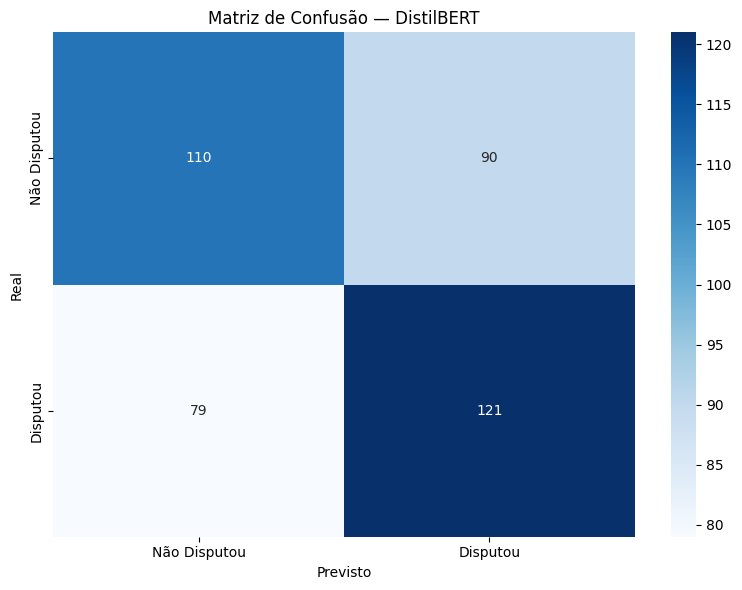

In [8]:
# Previsões no conjunto de teste
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print("=== AVALIAÇÃO DO MODELO ===")
print(f"\nClassification Report:")
print(classification_report(labels, preds, 
      target_names=['Não Disputou', 'Disputou']))

# Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Disputou', 'Disputou'],
            yticklabels=['Não Disputou', 'Disputou'])
ax.set_title('Matriz de Confusão — DistilBERT')
ax.set_ylabel('Real')
ax.set_xlabel('Previsto')
plt.tight_layout()
plt.show()

In [9]:
import joblib

# Salva modelo e tokenizador
model.save_pretrained('../models/distilbert_complaints')
tokenizer.save_pretrained('../models/distilbert_complaints')

print("Modelo salvo em models/distilbert_complaints/")

# Demonstração com textos reais
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        truncation=True,
        max_length=512,
        padding='max_length',
        return_tensors='pt'
    )
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = torch.softmax(outputs.logits, dim=-1)
    pred = torch.argmax(probs).item()
    confidence = probs[0][pred].item()
    
    label = "INSATISFEITO (Disputaria)" if pred == 1 else "SATISFEITO (Não Disputaria)"
    return label, confidence

# Testando com exemplos reais
exemplos = [
    "I have been trying to resolve this issue for months. The company never responds and keeps charging me fees I never agreed to. This is completely unacceptable.",
    "The bank resolved my complaint quickly and professionally. I am satisfied with the outcome and appreciate their prompt response.",
    "XXXX charged me twice for the same transaction and refuses to refund the money despite multiple calls and emails."
]

print("\n=== DEMONSTRAÇÃO DO MODELO ===\n")
for i, texto in enumerate(exemplos, 1):
    label, conf = predict_sentiment(texto)
    print(f"Exemplo {i}:")
    print(f"Texto: {texto[:100]}...")
    print(f"Previsão: {label} (confiança: {conf:.1%})")
    print()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo salvo em models/distilbert_complaints/

=== DEMONSTRAÇÃO DO MODELO ===

Exemplo 1:
Texto: I have been trying to resolve this issue for months. The company never responds and keeps charging m...
Previsão: SATISFEITO (Não Disputaria) (confiança: 53.5%)

Exemplo 2:
Texto: The bank resolved my complaint quickly and professionally. I am satisfied with the outcome and appre...
Previsão: SATISFEITO (Não Disputaria) (confiança: 52.2%)

Exemplo 3:
Texto: XXXX charged me twice for the same transaction and refuses to refund the money despite multiple call...
Previsão: SATISFEITO (Não Disputaria) (confiança: 53.0%)



## 7. Limitações e Próximos Passos

### Performance atual
- Accuracy: 58% (baseline aleatório: 50%)
- Confiança baixa nas previsões (~53%)
- Modelo com viés para classe majoritária

### Causa raiz
- Dataset reduzido: 2.000 exemplos (ideal: 50k+)
- Épocas limitadas: 2 (ideal: 5-10)
- Hardware: CPU (ideal: GPU)

### Para produção
- Fine-tuning com dataset completo (164k exemplos)
- GPU cloud (Google Colab Pro, AWS SageMaker)
- Aumentar épocas para 5-10
- Experimentar modelos menores especializados em finanças
  (FinBERT — pré-treinado em textos financeiros)

### FinBERT
Modelo BERT pré-treinado especificamente em textos financeiros.
Partiria de um conhecimento de domínio muito mais relevante para
reclamações bancárias do que o BERT genérico.